In [ ]:
# ── Notebook parameters ─────────────────────────────────────────
# Defaults for interactive use. extract_notebook_figures.py will
# override these via a cell injected right below this one.
#
# Add notebook-level globals here, e.g.:
CHECKPOINT_DIR  = "../outputs/checkpoints/wandb-xxx"
CHECKPOINT_FILE = "step_xxx.pt"



# Functional PCA — Learned Isometry vs. Baselines

This notebook accompanies `fpca.py`. It is **dataset-agnostic** *and*
**channel-agnostic**: every quantity (`CHANNELS_DIM`, `COORDS_DIM`,
resolution, drop fraction, dictionary parameters, ...) is read from the
saved Hydra `config.yaml`, so the same notebook works for grayscale
(`C=1`, e.g. CelebA-HQ + `grayscale: True`) and RGB (`C=3`) checkpoints,
as well as for synthetic scalar function classes.

All visualisation goes through the canonical helpers in
`notebook_helpers.py` — `field_to_img`, `to_rgb_image`, `render`,
`show_field`, `plot_atom_mosaic`, `scatter_signal`, `visualize_generator_U`
— so per-notebook copies of the same logic are not allowed; please edit
the helpers if you need to change behaviour. The canonical visualisation
grid is always `SquareSampler(stratified=True, add_noise=False).sample(N_VIS)`
(ij layout: `coords[i*N+j] = (x_i, y_j)`).

For datasets that pre-compute their own pixel grid in *yx* layout (CelebA's
`_full_coords` has y outer, x inner) we permute the stored signals into ij
layout via `yx_to_ij` so the rest of the notebook can use the unified
helpers without flipping conventions.

Sections:
1. Setup
2. Canonical grid & corpus peek
3. **Pushforward of Fourier atoms** (loaded checkpoint)
4. **Generator field $U(t, x)$ and rotation $K_R$** (loaded checkpoint)
5. Mean function
6. Reconstruction with the learned basis
7. Baselines (PCA gold + interpolated PCA)
8. PSNR comparison

In [2]:
%load_ext autoreload
%autoreload 2

import sys, math
sys.path.insert(0, "..")

import numpy as np
import torch
import yaml
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
from hydra.utils import instantiate

from infidictionary.datasets import IrregularDataset
from infidictionary.dictionaries import InfiDictionary
from infidictionary.networks import NeuralField
from infidictionary.neural_isometries import NeuralIsometry, IdentityIsometry
from infidictionary.recon import get_reconstructions
from infidictionary.domain_samplers import SquareSampler

from notebook_helpers import (
    field_to_img, to_rgb_image, render, show_field, visualize_generator_U,
    yx_to_ij, coords_yx_to_ij,
    psnr, plot_recon_grid, psnr_matrix, plot_psnr_line_chart,
    plot_atoms_comparison,
    plot_atom_mosaic, scatter_signal,
    fetch_validation_signals, build_corpus, pca_reconstruct,
    plot_spectral_compactness,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1. Setup — load checkpoint

Set `CHECKPOINT_DIR` and `CHECKPOINT_FILE`. Resolution, channel count, drop
fraction, dictionary parameters, etc. are *all* read from `config.yaml`.

In [ ]:


with open(f"{CHECKPOINT_DIR}/config.yaml") as f:
    conf = OmegaConf.create(yaml.safe_load(f))

neural_isometry: NeuralIsometry      = instantiate(conf.neural_isometry).to(device)
mean_function:   NeuralField         = instantiate(conf.mean_function).to(device)
initial_dictionary: InfiDictionary   = instantiate(conf.initial_dictionary)
function_generator: IrregularDataset = instantiate(conf.function_generator)

ckpt = torch.load(f"{CHECKPOINT_DIR}/{CHECKPOINT_FILE}", map_location=device, weights_only=False)
neural_isometry.load_state_dict(ckpt["models"]["neural_isometry"])
mean_function.load_state_dict(ckpt["models"]["mean_function"])

model_state_kwargs = OmegaConf.to_container(conf.get("model_state_kwargs", {"num_steps": 200}), resolve=True)
# model_state_kwargs = {'num_steps': 200}
neural_isometry.shuffle_model_state(**model_state_kwargs)
neural_isometry.eval()
mean_function.eval()

pullback_kwargs = OmegaConf.to_container(conf.get("pullback_pushforward_kwargs", {}), resolve=True)

COORDS_DIM   = int(conf.initial_dictionary.get("domain_dim", 2))
CHANNELS_DIM = int(conf.initial_dictionary.get("num_channels", 1))

print(f"Loaded   : {CHECKPOINT_DIR}/{CHECKPOINT_FILE}  (epoch {ckpt['epoch']})")
print(f"Metric   : {ckpt['metric']:.4f}  |  best: {ckpt['best_metric']:.4f}")
print(f"Generator: {type(function_generator).__name__}")
print(f"Domain   : d={COORDS_DIM}   |   channels: C={CHANNELS_DIM}")

## 2. Canonical grid & corpus peek

The visualisation grid `coords_full` always comes from
`SquareSampler(stratified=True, add_noise=False)` (ij layout). For
generators that store data on a *yx* pixel grid (e.g. CelebA), we set
`HAS_YX_DATA = True`; the helper `to_ij_signal(s)` converts a stored
`(M, N, C)` corpus into ij layout for display and PCA, and
`val_signals_ij` holds the held-out signals on the *same* grid as
`coords_full`.

In [4]:
N_VIS       = 64
coords_full = SquareSampler(stratified=True, add_noise=False).sample(N_VIS).to(device)
N_FULL      = coords_full.shape[0]
logabsdet_full = torch.zeros(N_FULL, device=device)

# Detect a yx-layout pre-computed grid (CelebA-style); if present, build a
# converter so we can reuse the stored corpus on the ij visualisation grid.
HAS_YX_DATA = hasattr(function_generator, "_full_coords")
if HAS_YX_DATA:
    coords_yx = function_generator._full_coords.to(device)
    n_yx      = int(round(math.sqrt(coords_yx.shape[0])))
    assert n_yx == N_VIS, (
        f"`function_generator._full_coords` is {n_yx}x{n_yx} but N_VIS={N_VIS}; "
        "set N_VIS to match the dataset resolution."
    )
    def to_ij_signal(s):     return yx_to_ij(s.to(device), N_VIS)
else:
    def to_ij_signal(s):     return s.to(device)

print(f"coords_full : {tuple(coords_full.shape)}  (SquareSampler ij layout, N={N_VIS}x{N_VIS})")
print(f"yx-layout corpus available : {HAS_YX_DATA}")

coords_full : (4096, 2)  (SquareSampler ij layout, N=64x64)
yx-layout corpus available : True


### Quick look at the corpus

`function_generator(seed)` returns the data in its native layout. If the
generator stores a regular yx grid (CelebA), we permute through
`yx_to_ij` so the rest of the notebook only sees ij-layout signals.

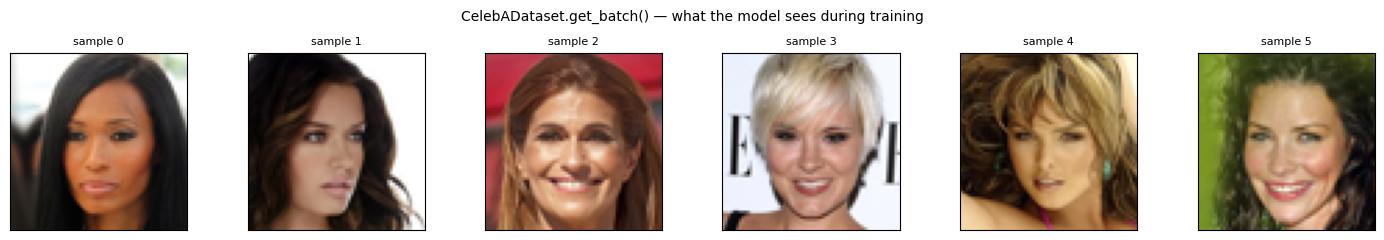

In [5]:
N_PEEK = 6
fig, axes = plt.subplots(1, N_PEEK, figsize=(2.4 * N_PEEK, 2.4))

# Same call the training loop makes every step.  All N_PEEK samples share one
# randomly-drawn drop pattern (a single CelebA "draw") — exactly what the model
# sees inside a single get_batch call.
coords_b, vals_b = function_generator.get_batch(batch_size=N_PEEK)   # (N', d), (B, N', C)

for j, ax in enumerate(np.atleast_1d(axes)):
    vals_j = vals_b[j]
    if HAS_YX_DATA and vals_j.shape[0] == N_FULL:
        show_field(ax, to_ij_signal(vals_j), N_VIS, title=f"sample {j}", cmap='Greys_r')
    elif vals_j.shape[0] == N_FULL:
        show_field(ax, vals_j.to(device), N_VIS, title=f"sample {j}", cmap='Greys_r')
    else:
        # irregular drop pattern — fall back to scatter (channel-agnostic helper)
        scatter_signal(ax, coords_b, vals_j,
                       title=f"sample {j} (N'={vals_j.shape[0]})", size_c1=15, cmap='Greys_r')

plt.suptitle(f"{type(function_generator).__name__}.get_batch() — what the model sees during training",
             fontsize=10)
plt.tight_layout(); plt.show()

## 3. Pushforward of Fourier atoms — full $(k_1, k_2)$ mosaic per channel

Same layout as the mosaics in `notebooks/euclidean_group.ipynb`: tile every
truncated atom $\phi_{k_1, k_2}$ on a regular grid, push it through the
isometry, and lay the deformed tiles out in a $(2K{-}1)\times(2K{-}1)$
mosaic — rows = $k_1$ (top row = largest $k_1$), columns = $k_2$.

Channel handling: the dictionary indices include a channel multi-index $c$,
so for $C > 1$ we render **one mosaic per input channel** side-by-side
(R / G / B for the CelebA case). Each tile is the per-pixel RGB of the
pushed atom (the pushforward generally mixes channels). For $C = 1$ the
extra index disappears and we get a single mosaic.

`NUM_TRUNCATED_VIS` controls the spatial half-bandwidth: the mosaic shows
$(2K{-}1)^2$ atoms per channel (e.g. $K=6 \Rightarrow 11\times 11$ tiles).
We render two figures: the original Fourier atoms $\phi_{k_1, k_2}$ and the
learned pushforward $Q\phi_{k_1, k_2}$.

In [ ]:
NUM_TRUNCATED_VIS = 6     # half-bandwidth: (2K-1)² atoms per channel
N_VIS_ATOM        = 128    # tile resolution (pixels per side)
TILE_SIZE         = 0.55  # inches per tile (mosaic figure scales linearly)

# ij-layout grid for tiles (matches field_to_img / to_rgb_image in notebook_helpers).
coords_atom = SquareSampler(stratified=True, add_noise=False).sample(N_VIS_ATOM).to(device)
lad_atom    = torch.zeros(coords_atom.shape[0], device=device)

# Sort by PMF ν descending for the linear comparison
indices_all = initial_dictionary.get_truncated_indices(NUM_TRUNCATED_VIS).to(device)
nu_all      = initial_dictionary.get_index_pmfs(indices_all)
order_nu    = nu_all.argsort(descending=True)
indices_nu  = indices_all[order_nu]

neural_isometry.shuffle_model_state(**model_state_kwargs)
with torch.no_grad():
    atoms_orig = initial_dictionary.get_atoms(coords_atom, indices_nu)               # (A, N, C)
    _, _, atoms_pushed = neural_isometry.pushforward(
        coords_atom, lad_atom, atoms_orig, **pullback_kwargs,
    )                                                                                 # (A, N, C)

# ── 2-row linear comparison (ν-ordered) ──────────────────────────────────────
for n_show_linear in [5, 12, 20]:
    plot_atoms_comparison(
        atoms_orig.detach().cpu(), atoms_pushed.detach().cpu(),
        n_vis=N_VIS_ATOM, n_show=n_show_linear, tile_size=TILE_SIZE,
        cmap='Greys_r',
        title=f"Top {n_show_linear} atoms ordered by ν (PMF descending)",
)

# ── 2D grid mosaic (k₁ × k₂ layout, both bases) ──────────────────────────────
plot_atom_mosaic(
    atoms_orig.detach().cpu(), indices_nu,
    title=r"Original Fourier atoms  $\phi_{k_1,k_2}$",
    n_vis=N_VIS_ATOM, tile_size=TILE_SIZE,
    cmap='Greys_r',
)
plot_atom_mosaic(
    atoms_pushed.detach().cpu(), indices_nu,
    title=r"Learned atoms (pushforward)  $Q\phi_{k_1,k_2}$",
    n_vis=N_VIS_ATOM, tile_size=TILE_SIZE,
    cmap='Greys_r',
)

# ── Zoom inset on the leftmost learned atom (arbitrary-resolution evaluation) ──
# Important: the Cayley step inside `pushforward` computes inner products as
# `(1/N) Σ_n U(x_n) · f(x_n)`, which only approximates `∫_{[0,1]²} U·f dx`
# when the points cover the full domain uniformly. If we fed pushforward a
# grid restricted to a sub-region, the same `(1/N) Σ_n` would instead average
# over that sub-region — a *different* operator — so the values would not be
# directly comparable to the full-domain pushforward.
#
# Coherent recipe: evaluate Qφ once on a single high-res grid covering all of
# `[0,1]²`, then derive both panels from that array (downsample for the left,
# crop for the right). Same operator, same scale, faithful colours.
ZOOM_ATOM_IDX  = 11      # index in indices_nu (0 = leftmost atom shown above)
ZOOM_LEFT      = 1/2.0 - 0.1   # x_min  (in [0, 1])
ZOOM_RIGHT     = 5/6.0   # x_max
ZOOM_DOWN      = 1/6. + 0.05  # y_min
ZOOM_UP        = 1/2. + 0.15   # y_max
ZOOM_FULL_RES  = 228    # left-panel display resolution (block-averaged from high-res)
ZOOM_RES       = 6    # right-panel target resolution inside the zoom box

import matplotlib.patches as mpatches

# Pick a high-res evaluation grid such that ZOOM_RES pixels land inside the box.
zoom_side     = max(ZOOM_RIGHT - ZOOM_LEFT, ZOOM_UP - ZOOM_DOWN)
ZOOM_HIGH_RES = max(ZOOM_FULL_RES, int(round(ZOOM_RES / max(zoom_side, 1e-9))))
print(f"High-res Q-evaluation grid: {ZOOM_HIGH_RES}x{ZOOM_HIGH_RES}  "
      f"(box side = {zoom_side:.3f}, → ≈{int(round(ZOOM_HIGH_RES * zoom_side))}px in the zoom)")

# Single full-domain pushforward — both panels are derived from this array.
coords_hi = SquareSampler(stratified=True, add_noise=False).sample(ZOOM_HIGH_RES).to(device)
lad_hi    = torch.zeros(coords_hi.shape[0], device=device)

neural_isometry.shuffle_model_state(**model_state_kwargs)
with torch.no_grad():
    idx_single = indices_nu[ZOOM_ATOM_IDX:ZOOM_ATOM_IDX + 1]
    atom_hi_orig = initial_dictionary.get_atoms(coords_hi, idx_single)
    _, _, atom_hi_pushed = neural_isometry.pushforward(
        coords_hi, lad_hi, atom_hi_orig, **pullback_kwargs,
    )

# (N², C) → (H_y, W_x, C) using the same ij→display convention as notebook_helpers.
img_hi = (
    atom_hi_pushed[0].detach().cpu().float()
    .reshape(ZOOM_HIGH_RES, ZOOM_HIGH_RES, -1).transpose(0, 1).numpy()
)
C = img_hi.shape[-1]

# Left panel: block-mean downsample to ZOOM_FULL_RES.
bs    = max(1, ZOOM_HIGH_RES // ZOOM_FULL_RES)
n_out = ZOOM_HIGH_RES // bs
img_full = (
    img_hi[: n_out * bs, : n_out * bs]
    .reshape(n_out, bs, n_out, bs, C)
    .mean(axis=(1, 3))
)

# Right panel: crop the zoom box directly from the high-res evaluation.
# Rows = y, cols = x; extent=[0,1,0,1] with origin='lower'.
x_lo = int(round(ZOOM_LEFT  * ZOOM_HIGH_RES))
x_hi = int(round(ZOOM_RIGHT * ZOOM_HIGH_RES))
y_lo = int(round(ZOOM_DOWN  * ZOOM_HIGH_RES))
y_hi = int(round(ZOOM_UP    * ZOOM_HIGH_RES))
img_zoom = img_hi[y_lo:y_hi, x_lo:x_hi]

# Shared normalization across both panels (no per-tile renormalization).
if C == 1:
    vmax = float(max(np.abs(img_full[..., 0]).max(), np.abs(img_zoom[..., 0]).max())) + 1e-8
    vmin = -vmax
    def _draw(ax, img, ext):
        ax.imshow(img[..., 0], origin='lower', extent=ext,
                  cmap='Greys_r', vmin=vmin, vmax=vmax)
else:
    lo = float(min(img_full[..., :3].min(), img_zoom[..., :3].min()))
    hi = float(max(img_full[..., :3].max(), img_zoom[..., :3].max()))
    rng = max(hi - lo, 1e-8)
    def _draw(ax, img, ext):
        x = np.clip((img[..., :3] - lo) / rng, 0.0, 1.0)
        ax.imshow(x, origin='lower', extent=ext)

fig, axes = plt.subplots(1, 2, figsize=(8.4, 4.2))

# Left: full domain at ZOOM_FULL_RES, with a red rectangle marking the zoom region.
_draw(axes[0], img_full, [0, 1, 0, 1])
axes[0].add_patch(mpatches.Rectangle(
    (ZOOM_LEFT, ZOOM_DOWN),
    ZOOM_RIGHT - ZOOM_LEFT, ZOOM_UP - ZOOM_DOWN,
    linewidth=2.0, edgecolor='red', facecolor='none',
))
axes[0].set_xticks([]); axes[0].set_yticks([]); axes[0].set_aspect('equal')
axes[0].set_title(
    fr"$Q\phi_{{{ZOOM_ATOM_IDX}}}$  on  $[0,1]^2$  at  {ZOOM_FULL_RES}$\times${ZOOM_FULL_RES}",
    fontsize=8,
)

# Right: same array, cropped to the zoom box.
_draw(axes[1], img_zoom, [ZOOM_LEFT, ZOOM_RIGHT, ZOOM_DOWN, ZOOM_UP])
axes[1].set_xticks([]); axes[1].set_yticks([]); axes[1].set_aspect('equal')
axes[1].set_title(
    fr"Zoom  $[{ZOOM_LEFT:.2f},{ZOOM_RIGHT:.2f}]\times[{ZOOM_DOWN:.2f},{ZOOM_UP:.2f}]$"
    f"  ({img_zoom.shape[1]}$\\times${img_zoom.shape[0]} px)",
    fontsize=8,
)
for sp in axes[1].spines.values():
    sp.set_edgecolor('red'); sp.set_linewidth(2.0)

plt.suptitle(
    f"Arbitrary-resolution evaluation",
    fontsize=10,
)
plt.tight_layout(); plt.show()


## 4. Generator field $U(t, x)$ and rotation $K_R(t)$

`visualize_generator_U` (the same one called from `eulerian_transform.ipynb`)
plots the rows of the **assembled** generator
$U(t, x) = \mathrm{function\_field}(t, x) + \sum_a w_a(t)\,\phi_a(x)$ at
several timesteps, plus a heatmap of the finite rotation
$\exp(K_R - K_R^\top)$.

In [7]:
my_timesteps = [0.0, 0.25, 0.50, 0.75, 0.8, 0.9, 0.85, 1.0]

In [ ]:
timesteps_U  = torch.tensor(my_timesteps)
N_VIS_U      = 64
coords_vis_U = SquareSampler(stratified=True, add_noise=False).sample(N_VIS_U).to(device)

visualize_generator_U(neural_isometry, coords_vis_U, N_VIS_U, timesteps_U, device, cmap='Greys_r', trunc=5)

In [ ]:

# ── Intermediate pushforward of a Fourier atom ──────────────────────────────
# Requires section 3 to have run (uses `indices_nu`).
#
# For each ODE time in TIMESTEPS_TRACK we run pushforward(end_time=t).
# At t=0 the ODE has zero width so every Cayley step returns f unchanged;
# the only active transform is the static channel pre-mix — which is the
# correct "starting point" of the learned flow.
ATOM_IDX_TRACK  = 11           # index into ν-sorted `indices_nu`; try 1, 3, 6, 11, …
N_VIS_TRACK     = 64          # grid resolution for each frame

TIMESTEPS_TRACK = my_timesteps

coords_track = SquareSampler(stratified=True, add_noise=False).sample(N_VIS_TRACK).to(device)
lad_track    = torch.zeros(coords_track.shape[0], device=device)

# Freeze a single model state so the ODE path is identical across all frames.
neural_isometry.shuffle_model_state(**model_state_kwargs)
neural_isometry.eval()

# Strip start_time / end_time from pullback_kwargs — we supply those explicitly.
base_pf_kwargs = {k: v for k, v in pullback_kwargs.items()
                  if k not in ("start_time", "end_time")}

with torch.no_grad():
    idx_track = indices_nu[ATOM_IDX_TRACK : ATOM_IDX_TRACK + 1]          # (1, d+1)
    atom_src  = initial_dictionary.get_atoms(coords_track, idx_track)     # (1, N, C)

    frames_track = []
    for t in TIMESTEPS_TRACK:
        if t < 1e-3:
            frames_track.append(atom_src[0].detach().cpu().float())
            continue
        _, _, atom_t = neural_isometry.pushforward(
            coords_track, lad_track, atom_src,
            start_time=0.0, end_time=float(t),
            **base_pf_kwargs,
        )
        frames_track.append(atom_t[0].detach().cpu().float())   # (N², C)

# (N², C) → (N, N, C) in display orientation (ij → transpose → y-up for imshow)
C_dim  = frames_track[0].shape[-1]
all_np = [
    f.reshape(N_VIS_TRACK, N_VIS_TRACK, C_dim).transpose(0, 1).numpy()
    for f in frames_track
]

fig, axes = plt.subplots(1, len(TIMESTEPS_TRACK),
                         figsize=(3.2 * len(TIMESTEPS_TRACK), 3.6))
fig.suptitle(
    fr"Atom $\phi$ (ν-rank {ATOM_IDX_TRACK + 1}) pushed forward at intermediate ODE times",
    fontsize=11,
)

if C_dim == 1:
    vmax_t = max(np.abs(a[..., 0]).max() for a in all_np) + 1e-8
    for ax, img, t in zip(np.atleast_1d(axes), all_np, TIMESTEPS_TRACK):
        ax.imshow(img[..., 0], origin='lower', extent=[0, 1, 0, 1],
                  cmap='Greys_r', vmin=-vmax_t, vmax=vmax_t)
        ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect('equal')
        ax.set_title(f"$t = {t:.2f}$", fontsize=9)
else:
    # Normalise globally so colours are comparable across frames.
    lo  = min(a.min() for a in all_np)
    hi  = max(a.max() for a in all_np)
    rng = max(hi - lo, 1e-8)
    for ax, img, t in zip(np.atleast_1d(axes), all_np, TIMESTEPS_TRACK):
        rgb = np.clip((img[..., :3] - lo) / rng, 0.0, 1.0)
        ax.imshow(rgb, origin='lower', extent=[0, 1, 0, 1])
        ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect('equal')
        ax.set_title(f"$t = {t:.2f}$", fontsize=9)

plt.tight_layout()
plt.show()


## 5. Learned mean function $\mu(x)$

The mean function is co-trained with the isometry; for FPCA it minimises
MSE to the dataset mean and the isometry diagonalises the covariance of
the zero-centred field.

In [ ]:
with torch.no_grad():
    mean_vals = mean_function(coords_full)   # (N, C)

fig, ax = plt.subplots(figsize=(4.6, 4.6))
show_field(ax, mean_vals, N_VIS,
           title=fr"Learned mean function  $\mu(x)$  (C={CHANNELS_DIM})", cmap='Greys_r')
plt.tight_layout(); plt.show()

## 6. Reconstruction with the learned basis

For a held-out batch of signals, compare the truncated reconstruction in
the **Fourier** basis (identity isometry) with the truncated reconstruction
in the **learned** basis $\{Q\phi_k\}$. PSNR is shown above each tile.

Validation signals come from `fetch_validation_signals` — for CelebA we
permute through `yx_to_ij` so the reconstruction grid matches `coords_full`.

In [ ]:
TRUNCATION_LIST = [1, 2, 3, 5, 10, 15]
N_VAL           = 4
val_seed_offset = getattr(function_generator, "n_images", 0) * \
                  getattr(function_generator, "n_drop_draws", 1)

n_atoms_list = [initial_dictionary.get_truncated_indices(t).shape[0] for t in TRUNCATION_LIST]
print(f"Truncation factors : {TRUNCATION_LIST}")
print(f"Atoms used         : {n_atoms_list}")

val_signals_raw = fetch_validation_signals(
    function_generator, coords_full, N_VAL, device, val_seed_offset=val_seed_offset,
)
val_signals = to_ij_signal(val_signals_raw)
print(f"Validation signals : {tuple(val_signals.shape)}  (ij layout)")

In [ ]:
identity_isometry = IdentityIsometry().to(device).eval()
neural_isometry.shuffle_model_state(**model_state_kwargs)
neural_isometry.eval()

with torch.no_grad():
    fourier_recons, learned_recons = [], []
    for trunc in TRUNCATION_LIST:
        fourier_recons.append(get_reconstructions(
            coords=coords_full, functions=val_signals,
            neural_isometry=identity_isometry, mean_function=mean_function,
            dictionary=initial_dictionary, truncation_factor=trunc, **pullback_kwargs,
        ).cpu())
        learned_recons.append(get_reconstructions(
            coords=coords_full, functions=val_signals,
            neural_isometry=neural_isometry, mean_function=mean_function,
            dictionary=initial_dictionary, truncation_factor=trunc, **pullback_kwargs,
        ).cpu())
print(f"Computed {len(TRUNCATION_LIST)} truncation levels x {N_VAL} signals "
      f"for Fourier and Learned bases.")

In [ ]:
val_signals_cpu = val_signals.cpu()
metrics_part = plot_recon_grid(
    methods=[("Learned", learned_recons), ("Fourier", fourier_recons)],
    val_imgs_cpu=val_signals_cpu, n_atoms_list=n_atoms_list, n=N_VIS,
    cmap='Greys_r',
)
learned_metrics = metrics_part["Learned"]
fourier_metrics = metrics_part["Fourier"]

## 7. Baselines

* **PCA Gold** — classical PCA on the *full-grid* corpus.
* **PCA Interpolated** — classical PCA after interpolating each *sparse*
  observation back to the full grid (only meaningful for generators with
  pre-computed drop patterns; skipped otherwise).

In [ ]:
corpus_raw = build_corpus(function_generator, coords_full).float()  # (M, N, C) in native layout
corpus     = to_ij_signal(corpus_raw).cpu()                          # (M, N, C) in ij layout
M, N, C    = corpus.shape
D          = N * C
X_flat     = corpus.reshape(M, D)
print(f"Corpus shape: {tuple(corpus.shape)}   D = N*C = {D}   (ij layout)")

import os
_run_name  = os.path.basename(os.path.normpath(CHECKPOINT_DIR))
_cache_dir = os.path.normpath(os.path.join(CHECKPOINT_DIR, "..", "..", "notebooks", _run_name))
_cache_gold = os.path.join(_cache_dir, "pca_gold.npz")

if os.path.exists(_cache_gold):
    print(f"[cache hit] Loading PCA gold from {_cache_gold}")
    _d = np.load(_cache_gold)
    mean_face_flat = torch.from_numpy(_d["mean_face_flat"])
    S              = torch.from_numpy(_d["S"])
    Vh             = torch.from_numpy(_d["Vh"])
else:
    print("[cache miss] Computing SVD (may be slow)…")
    mean_face_flat = X_flat.mean(dim=0)
    X_centered     = X_flat - mean_face_flat
    _, S, Vh       = torch.linalg.svd(X_centered, full_matrices=False)
    os.makedirs(_cache_dir, exist_ok=True)
    np.savez_compressed(_cache_gold,
                        mean_face_flat=mean_face_flat.numpy(),
                        S=S.numpy(), Vh=Vh.numpy())
    print(f"[cache saved] {_cache_gold}")

ev = (S ** 2) / (S ** 2).sum()
for k in [1, 5, 10, 20, 50, 100]:
    if k <= len(ev):
        print(f"  Top-{k:>3d} PCs explain {ev[:k].sum().item()*100:5.1f}% of variance")


In [ ]:
K_SHOW = min(12, Vh.shape[0])
mean_img        = mean_face_flat.reshape(N, C)
gold_components = Vh[:K_SHOW].reshape(K_SHOW, N, C)

fig, axes = plt.subplots(1, K_SHOW + 1, figsize=(2.4 * (K_SHOW + 1), 2.4))
show_field(axes[0], mean_img, N_VIS, title="dataset mean", cmap='Greys_r')
for i in range(K_SHOW):
    show_field(axes[i + 1], gold_components[i], N_VIS, title=f"PC {i+1}\n$\\sigma$={S[i]:.1f}", cmap='Greys_r')
plt.suptitle(f"PCA Gold — top components from {M} signals on the full {N_VIS}x{N_VIS} grid",
             fontsize=11)
plt.tight_layout(); plt.show()

In [ ]:
from scipy.interpolate import griddata as scipy_griddata
from tqdm import tqdm

HAVE_DROP_PATTERNS = (
    hasattr(function_generator, "_drop_patterns") and
    hasattr(function_generator, "_drop_coords") and
    hasattr(function_generator, "images")
)

if HAVE_DROP_PATTERNS:
    import os
    _cache_interp = os.path.join(_cache_dir, "pca_interp.npz")

    if os.path.exists(_cache_interp):
        print(f"[cache hit] Loading PCA interp from {_cache_interp}")
        _d         = np.load(_cache_interp)
        mean_interp = torch.from_numpy(_d["mean_interp"])
        S_i         = torch.from_numpy(_d["S_i"])
        Vh_interp   = torch.from_numpy(_d["Vh_interp"])
        print(f"Vh_interp : {tuple(Vh_interp.shape)}  (ij layout, from cache)")
    else:
        full_coords_yx_np = function_generator._full_coords.detach().cpu().numpy()
        n_total = function_generator.n_images * function_generator.n_drop_draws
        print(f"Drop fraction : {function_generator.drop_fraction*100:.0f}%")
        print(f"Drop draws    : {function_generator.n_drop_draws} per image  ->  {n_total} rows")
        print(f"Pattern sizes : min={min(len(p) for p in function_generator._drop_patterns)}  "
              f"max={max(len(p) for p in function_generator._drop_patterns)} pixels kept")

        def interp_to_full(sparse_coords_np, vals_np):
            filled = scipy_griddata(sparse_coords_np, vals_np, full_coords_yx_np,
                                    method="linear", fill_value=float("nan"))
            nan_mask = np.isnan(filled[:, 0])
            if nan_mask.any():
                filled[nan_mask] = scipy_griddata(sparse_coords_np, vals_np,
                                                  full_coords_yx_np[nan_mask], method="nearest")
            return filled

        interp_signals = []
        for seed in tqdm(range(n_total), desc="Interpolating"):
            sparse_coords, vals = function_generator(seed)
            interp_signals.append(interp_to_full(
                sparse_coords.detach().cpu().numpy(),
                vals.detach().cpu().float().numpy(),
            ))
        Mtot = len(interp_signals)
        corpus_interp_yx = torch.from_numpy(np.stack(interp_signals, axis=0)).float()
        corpus_interp_ij = yx_to_ij(corpus_interp_yx, N_VIS)
        X_interp_flat    = corpus_interp_ij.reshape(Mtot, D)
        mean_interp      = X_interp_flat.mean(dim=0)
        _, S_i, Vh_interp = torch.linalg.svd(X_interp_flat - mean_interp, full_matrices=False)
        print(f"\nVh_interp : {tuple(Vh_interp.shape)}  (ij layout)")

        os.makedirs(_cache_dir, exist_ok=True)
        np.savez_compressed(_cache_interp,
                            mean_interp=mean_interp.numpy(),
                            S_i=S_i.numpy(),
                            Vh_interp=Vh_interp.numpy())
        print(f"[cache saved] {_cache_interp}")

    ev_g = (S    ** 2) / (S    ** 2).sum()
    ev_i = (S_i  ** 2) / (S_i  ** 2).sum()
    print(f"\n{'K':>4} | {'Gold cumvar':>12} | {'Interp cumvar':>14}")
    print("-" * 40)
    for k in [1, 5, 10, 20, 50]:
        if k <= len(S):
            print(f"{k:>4} | {ev_g[:k].sum()*100:>11.1f}% | {ev_i[:k].sum()*100:>13.1f}%")
else:
    print(f"Generator {type(function_generator).__name__} has no sparse drop "
          "patterns — skipping the interpolated-PCA baseline.")
    Vh_interp, mean_interp = None, None


In [ ]:
with torch.no_grad():
    pca_gold_recons = pca_reconstruct(
        val_signals, mean_face_flat, Vh, n_atoms_list, N_FULL, CHANNELS_DIM, device,
    )
    pca_interp_recons = (
        pca_reconstruct(val_signals, mean_interp, Vh_interp, n_atoms_list,
                         N_FULL, CHANNELS_DIM, device)
        if Vh_interp is not None else None
    )

methods_for_grid = [("Learned",  learned_recons),
                    ("Fourier",  fourier_recons),
                    ("PCA Gold", pca_gold_recons)]
if pca_interp_recons is not None:
    methods_for_grid.append((f"PCA Interp ({function_generator.drop_fraction*100:.0f}% dropped)",
                             pca_interp_recons))

all_metrics = plot_recon_grid(
    methods=methods_for_grid, val_imgs_cpu=val_signals_cpu,
    n_atoms_list=n_atoms_list, n=N_VIS, cmap='Greys_r'
)

## 8. PSNR vs number of atoms

One subplot per validation signal, bars grouped by truncation level.

In [ ]:
methods = [
    ("Learned",  all_metrics["Learned"]),
    ("Fourier",  all_metrics["Fourier"]),
    # ("PCA Gold", all_metrics["PCA Gold"]),
]
# if pca_interp_recons is not None:
#     methods.append(("PCA Interp",
#                     all_metrics[f"PCA Interp ({function_generator.drop_fraction*100:.0f}% dropped)"]))

L         = val_signals_cpu.shape[0]
M_methods = len(methods)
bar_w     = 0.8 / M_methods
xs        = np.arange(len(n_atoms_list))
colors    = plt.cm.tab10(np.arange(M_methods))

fig, axes = plt.subplots(1, L, figsize=(4.4 * L, 4.2), sharey=True, squeeze=False)
for l, ax in enumerate(axes[0]):
    for m_idx, (method_name, metrics) in enumerate(methods):
        psnrs   = [pp for (img, _, pp) in metrics if img == l]
        offsets = (np.arange(M_methods) - (M_methods - 1) / 2) * bar_w
        ax.bar(xs + offsets[m_idx], psnrs, width=bar_w,
               color=colors[m_idx], label=method_name)
    ax.set_xticks(xs); ax.set_xticklabels(n_atoms_list)
    ax.set_xlabel("Number of atoms")
    ax.set_title(f"signal {l}")
    ax.grid(axis="y", alpha=0.3)
    if l == 0:
        ax.set_ylabel("PSNR (dB)")
    if l == L - 1:
        ax.legend(title="method", fontsize=8, title_fontsize=8)
plt.suptitle("PSNR vs number of atoms", fontsize=12)
plt.tight_layout(); plt.show()

In [ ]:

# ── In-distribution: all training images ─────────────────────────────────
N_IN = function_generator.n_images if hasattr(function_generator, "images") else 50
N_OOD_SHOW = 4   # how many OOD images to show in the reconstruction grid

val_in_raw = fetch_validation_signals(
    function_generator, coords_full, N_IN, device, val_seed_offset=val_seed_offset,
)
val_in     = to_ij_signal(val_in_raw)
val_in_cpu = val_in.cpu()
L_in       = val_in.shape[0]
print(f"In-distribution signals : {tuple(val_in.shape)}")

# ── Out-of-distribution: load next images beyond the training split ────────
if hasattr(function_generator, "images"):
    import torchvision.transforms as TF
    from datasets import load_dataset as hf_load_dataset

    _res   = function_generator.resolution
    _N_pix = _res * _res
    _tfs   = [TF.Resize((_res, _res), interpolation=TF.InterpolationMode.BICUBIC)]
    if function_generator.grayscale:
        _tfs.append(TF.Grayscale(num_output_channels=1))
    _tfs.append(TF.ToTensor())
    _to_tensor = TF.Compose(_tfs)

    N_OOD = N_IN   # same size as in-distribution for a fair comparison
    print(f"Loading {N_OOD} OOD images (skipping first {N_IN} from shuffled train split)…")
    _ds  = hf_load_dataset("mattymchen/celeba-hq", split="train", streaming=True)
    # Must use the identical shuffle as CelebADataset.__init__ so that
    # positions 0..N_IN-1 of this stream == training images and
    # positions N_IN..2*N_IN-1 == true OOD (non-overlapping, same distribution).
    # This also ensures pca_reconstruct(val_ood, ...) inside _all_recons
    # operates on correctly-shuffled OOD images.
    _ds  = _ds.shuffle(seed=42, buffer_size=10_000)
    _ood = []
    for _i, _sample in enumerate(_ds):
        if _i < N_IN:
            continue
        if len(_ood) >= N_OOD:
            break
        _t = _to_tensor(_sample["image"]).permute(1, 2, 0).flip(0)   # (H, W, C)
        _ood.append(_t.reshape(_N_pix, function_generator.channels))

    val_ood_yx  = torch.stack(_ood, dim=0).to(device)          # yx layout
    val_ood     = yx_to_ij(val_ood_yx, _res)                   # ij layout
    val_ood_cpu = val_ood.cpu()
    L_ood       = val_ood.shape[0]
    print(f"OOD signals           : {tuple(val_ood.shape)}")
    has_ood = True
else:
    has_ood = False
    print("Generator is not CelebA-style — OOD loading skipped.")

# ── Compute all reconstructions (single model state for fairness) ─────────
neural_isometry.shuffle_model_state(**model_state_kwargs)
neural_isometry.eval()

def _all_recons(val_signals):
    fourier_r, learned_r = [], []
    with torch.no_grad():
        for trunc in TRUNCATION_LIST:
            fourier_r.append(get_reconstructions(
                coords=coords_full, functions=val_signals,
                neural_isometry=identity_isometry, mean_function=mean_function,
                dictionary=initial_dictionary, truncation_factor=trunc, **pullback_kwargs,
            ).cpu())
            learned_r.append(get_reconstructions(
                coords=coords_full, functions=val_signals,
                neural_isometry=neural_isometry, mean_function=mean_function,
                dictionary=initial_dictionary, truncation_factor=trunc, **pullback_kwargs,
            ).cpu())
        pca_gold_r = pca_reconstruct(
            val_signals, mean_face_flat, Vh, n_atoms_list, N_FULL, CHANNELS_DIM, device,
        )
        pca_interp_r = (
            pca_reconstruct(val_signals, mean_interp, Vh_interp, n_atoms_list, N_FULL, CHANNELS_DIM, device)
            if Vh_interp is not None else None
        )
    return fourier_r, learned_r, pca_gold_r, pca_interp_r

fourier_in, learned_in, pca_gold_in, pca_interp_in = _all_recons(val_in)
if has_ood:
    fourier_ood, learned_ood, pca_gold_ood, pca_interp_ood = _all_recons(val_ood)
print("Reconstructions complete.")

# ── PSNR matrix helper ────────────────────────────────────────────────────
def _build_method_pms(fourier_r, learned_r, pca_gold_r, pca_interp_r, ref_cpu):
    pms = [
        ("Learned",  psnr_matrix(learned_r,  ref_cpu), plt.cm.tab10(0)),
        ("Fourier",  psnr_matrix(fourier_r,  ref_cpu), plt.cm.tab10(1)),
        # ("PCA Gold", psnr_matrix(pca_gold_r, ref_cpu), plt.cm.tab10(2)),
    ]
    # if pca_interp_r is not None:
    #     drop_pct = f"{function_generator.drop_fraction * 100:.0f}%"
    #     pms.append((f"PCA Interp ({drop_pct} dropped)",
    #                 psnr_matrix(pca_interp_r, ref_cpu), plt.cm.tab10(3)))
    return pms

pms_in  = _build_method_pms(fourier_in,  learned_in,  pca_gold_in,  pca_interp_in,  val_in_cpu)
pms_ood = (_build_method_pms(fourier_ood, learned_ood, pca_gold_ood, pca_interp_ood, val_ood_cpu)
           if has_ood else None)

# ── Side-by-side PSNR line plots ─────────────────────────────────────────
plot_psnr_line_chart(
    in_methods=pms_in,
    n_atoms_list=n_atoms_list,
    ood_methods=pms_ood if has_ood else None,
)

# ── OOD reconstruction grid (4 images) ───────────────────────────────────
if has_ood:
    val_ood_show = val_ood[:N_OOD_SHOW].cpu()
    ood_grid_methods = [
        ("Learned",  [r[:N_OOD_SHOW] for r in learned_ood]),
        ("Fourier",  [r[:N_OOD_SHOW] for r in fourier_ood]),
        ("PCA Gold", [r[:N_OOD_SHOW] for r in pca_gold_ood]),
    ]
    if pca_interp_ood is not None:
        drop_pct = f"{function_generator.drop_fraction * 100:.0f}%"
        ood_grid_methods.append(
            (f"PCA Interp ({drop_pct} dropped)", [r[:N_OOD_SHOW] for r in pca_interp_ood])
        )
    plot_recon_grid(
        methods=ood_grid_methods,
        val_imgs_cpu=val_ood_show,
        n_atoms_list=n_atoms_list,
        n=N_VIS,
        cmap='Greys_r',
    )


## 9. Spectral compactness — power-law spectrum of Fourier vs. learned basis

For each image $f$ in a held-out batch, compute the projection coefficients
in both bases, ordered by $\nu(k)$ (prior PMF) descending:

$$c_k^F = \langle f - \mu,\, \varphi_k\rangle, \qquad
  c_k^L = \langle Q^*(f - \mu),\, \varphi_k\rangle.$$

If the FPCA model is well-trained, the learned basis packs more energy into
the first few atoms — the learned curve should **start higher** and **decay
faster** than the Fourier curve.

In [ ]:
from infidictionary.utils import pairwise_inner_product

# Parameters
N_SPEC = 300   # images to average over
K_SPEC = 5    # include all atoms with |k|_∞ ≤ K_SPEC - 1

# Atoms sorted by PMF ν descending
spec_idx = initial_dictionary.get_truncated_indices(K_SPEC).to(device)  # (A, d+1)
spec_nu  = initial_dictionary.get_index_pmfs(spec_idx)                  # (A,)
order    = spec_nu.argsort(descending=True)
spec_idx = spec_idx[order]
spec_nu  = spec_nu[order].cpu()
A_spec   = spec_idx.shape[0]
print(f"{A_spec} atoms, ν ∈ [{spec_nu[-1]:.2e}, {spec_nu[0]:.2e}]")

# Build image batch — reuse corpus if section 7 already ran, else sample fresh
try:
    imgs = to_ij_signal(corpus_raw[:N_SPEC].float().to(device))
except NameError:
    imgs = to_ij_signal(
        fetch_validation_signals(function_generator, coords_full, N_SPEC, device)
    )
imgs = imgs[:N_SPEC].to(device)   # (M, N, C)
M_spec = imgs.shape[0]
print(f"Using {M_spec} images")

In [ ]:
neural_isometry.shuffle_model_state(**model_state_kwargs)
neural_isometry.eval()

with torch.no_grad():
    mu       = mean_function(coords_full)           # (N, C)
    centered = imgs - mu.unsqueeze(0)               # (M, N, C)
    lad      = logabsdet_full                       # (N,)

    # Atoms evaluated on the visualisation grid (shared for Fourier coeff)
    atoms_tgt = initial_dictionary.get_atoms(coords_full, spec_idx)  # (A, N, C)

    # Fourier coefficients: <phi_a, f-mu>
    c_F = pairwise_inner_product(atoms_tgt, centered, lad)            # (A, M)

    # Learned-basis coefficients: Q*(f-mu) projected onto phi_a
    src_coords, src_lad, pulled = neural_isometry.pullback(
        tgt_coords=coords_full,
        tgt_logabsdet=lad,
        tgt_field=centered,
        **pullback_kwargs,
    )  # pulled: (M, N_src, C)
    atoms_src = initial_dictionary.get_atoms(src_coords, spec_idx)    # (A, N_src, C)
    c_L = pairwise_inner_product(atoms_src, pulled, src_lad)           # (A, M)

sq_F     = c_F.pow(2).cpu()          # (A, M) per-image squared coefficients
sq_L     = c_L.pow(2).cpu()
energy_F = sq_F.mean(dim=-1)         # (A,) mean squared coeff
energy_L = sq_L.mean(dim=-1)
print(f"Total energy — Fourier: {energy_F.sum():.4f}  |  Learned: {energy_L.sum():.4f}")

In [ ]:
import numpy as np

N_VIOLIN = 10   # how many top-ν atoms to show in the per-atom panel

# Per-image cumulative fraction of total energy: (A, M)
# Normalise per image so each trace integrates to 1.
cum_F_per_img = sq_F.cumsum(0) / (sq_F.sum(0, keepdim=True) + 1e-15)
cum_L_per_img = sq_L.cumsum(0) / (sq_L.sum(0, keepdim=True) + 1e-15)

cum_F_mean = cum_F_per_img.mean(dim=1).numpy()    # (A,)
cum_F_std  = cum_F_per_img.std(dim=1).numpy()
cum_L_mean = cum_L_per_img.mean(dim=1).numpy()
cum_L_std  = cum_L_per_img.std(dim=1).numpy()

x = np.arange(1, A_spec + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

plot_spectral_compactness(
    [
        dict(label="Fourier", xs=x, mean=cum_F_mean, std=cum_F_std, color='C0'),
        dict(label="Learned", xs=x, mean=cum_L_mean, std=cum_L_std, color='C3'),
    ],
    xlabel="atom rank  (ν descending)",
    xscale="log",
    axes=(axes[0], axes[1]),
)

# ── 3. Per-atom mean ± std  (top N_VIOLIN atoms) ─────────────────────────
ax  = axes[2]
nv  = min(N_VIOLIN, A_spec)
pos = np.arange(1, nv + 1)

mean_F = sq_F[:nv].mean(dim=-1).numpy()   # (nv,)
std_F  = sq_F[:nv].std(dim=-1).numpy()
mean_L = sq_L[:nv].mean(dim=-1).numpy()
std_L  = sq_L[:nv].std(dim=-1).numpy()

ax.plot(pos, mean_F, 'o-', lw=1.5, ms=4, color='C0', label="Fourier")
ax.fill_between(pos, np.maximum(mean_F - std_F, 0), mean_F + std_F,
                alpha=0.25, color='C0')
ax.plot(pos, mean_L, 'o-', lw=1.5, ms=4, color='C3', label="Learned")
ax.fill_between(pos, np.maximum(mean_L - std_L, 0), mean_L + std_L,
                alpha=0.25, color='C3')
ax.set_xticks(pos)
ax.set_xticklabels([str(k) for k in pos], fontsize=7)
ax.set_xlabel("atom rank  (ν descending, with tiebreak)")
ax.set_ylabel("$c_k^2$  (mean ± 1 std)")
ax.set_title(f"Per-image energy  (top {nv} atoms)")
ax.legend(); ax.grid(True, alpha=0.3, axis="y")

plt.suptitle(
    f"Spectral compactness — Fourier vs. Learned basis  "
    f"({M_spec} images, {A_spec} atoms, |k|_∞ ≤ {K_SPEC - 1})",
    y=1.02,
)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────
print(f"\n{'Threshold':>10}  {'Fourier':>10}  {'Learned':>10}  {'gain':>8}")
for frac in [0.50, 0.75, 0.90]:
    nf = int((cum_F_mean < frac).sum()) + 1
    nl = int((cum_L_mean < frac).sum()) + 1
    gain = (nf - nl) / max(nf, 1) * 100
    print(f"{frac*100:>9.0f}%  {nf:>9d}  {nl:>9d}  {gain:>+7.1f}%")


In [ ]:

# ── Spectral compactness on OOD images ────────────────────────────────────
# Reuses spec_idx / N_VIOLIN from section 9.
# Requires the OOD cell (section 8) to have run first.

if has_ood:

    neural_isometry.shuffle_model_state(**model_state_kwargs)
    neural_isometry.eval()

    with torch.no_grad():
        mu_ood       = mean_function(coords_full)                                # (N, C)
        centered_ood = val_ood.to(device) - mu_ood.unsqueeze(0)                 # (L_ood, N, C)

        atoms_tgt_ood = initial_dictionary.get_atoms(coords_full, spec_idx)     # (A, N, C)
        c_F_ood = pairwise_inner_product(atoms_tgt_ood, centered_ood, lad)      # (A, L_ood)

        src_coords_ood, src_lad_ood, pulled_ood = neural_isometry.pullback(
            tgt_coords=coords_full,
            tgt_logabsdet=lad,
            tgt_field=centered_ood,
            **pullback_kwargs,
        )
        atoms_src_ood = initial_dictionary.get_atoms(src_coords_ood, spec_idx)  # (A, N_src, C)
        c_L_ood = pairwise_inner_product(atoms_src_ood, pulled_ood, src_lad_ood) # (A, L_ood)

    sq_F_ood     = c_F_ood.pow(2).cpu()     # (A, L_ood)
    sq_L_ood     = c_L_ood.pow(2).cpu()
    energy_F_ood = sq_F_ood.mean(dim=-1)
    energy_L_ood = sq_L_ood.mean(dim=-1)
    print(f"OOD total energy — Fourier: {energy_F_ood.sum():.4f}  |  Learned: {energy_L_ood.sum():.4f}")

    # Per-image cumulative fraction of total energy: (A, L_ood)
    cum_F_ood_per_img = sq_F_ood.cumsum(0) / (sq_F_ood.sum(0, keepdim=True) + 1e-15)
    cum_L_ood_per_img = sq_L_ood.cumsum(0) / (sq_L_ood.sum(0, keepdim=True) + 1e-15)

    cum_F_ood_mean = cum_F_ood_per_img.mean(dim=1).numpy()
    cum_F_ood_std  = cum_F_ood_per_img.std(dim=1).numpy()
    cum_L_ood_mean = cum_L_ood_per_img.mean(dim=1).numpy()
    cum_L_ood_std  = cum_L_ood_per_img.std(dim=1).numpy()

    x_ood = np.arange(1, A_spec + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

    plot_spectral_compactness(
        [
            dict(label="Fourier", xs=x_ood, mean=cum_F_ood_mean, std=cum_F_ood_std, color='C0'),
            dict(label="Learned", xs=x_ood, mean=cum_L_ood_mean, std=cum_L_ood_std, color='C3'),
        ],
        xlabel="atom rank  (ν descending)",
        xscale="log",
        axes=(axes[0], axes[1]),
    )

    # ── Per-atom mean ± std  (top N_VIOLIN atoms) ─────────────────────────
    ax  = axes[2]
    nv  = min(N_VIOLIN, A_spec)
    pos = np.arange(1, nv + 1)

    mean_F_ood = sq_F_ood[:nv].mean(dim=-1).numpy()
    std_F_ood  = sq_F_ood[:nv].std(dim=-1).numpy()
    mean_L_ood = sq_L_ood[:nv].mean(dim=-1).numpy()
    std_L_ood  = sq_L_ood[:nv].std(dim=-1).numpy()

    ax.plot(pos, mean_F_ood, 'o-', lw=1.5, ms=4, color='C0', label="Fourier")
    ax.fill_between(pos, np.maximum(mean_F_ood - std_F_ood, 0), mean_F_ood + std_F_ood,
                    alpha=0.25, color='C0')
    ax.plot(pos, mean_L_ood, 'o-', lw=1.5, ms=4, color='C3', label="Learned")
    ax.fill_between(pos, np.maximum(mean_L_ood - std_L_ood, 0), mean_L_ood + std_L_ood,
                    alpha=0.25, color='C3')
    ax.set_xticks(pos)
    ax.set_xticklabels([str(k) for k in pos], fontsize=7)
    ax.set_xlabel("atom rank  (ν descending, with tiebreak)")
    ax.set_ylabel("$c_k^2$  (mean ± 1 std)")
    ax.set_title(f"Per-image energy  (top {nv} atoms)")
    ax.legend(); ax.grid(True, alpha=0.3, axis="y")

    plt.suptitle(
        f"Spectral compactness — OOD images  "
        f"({L_ood} images, {A_spec} atoms, |k|_∞ ≤ {K_SPEC - 1})",
        y=1.02,
    )
    plt.tight_layout()
    plt.show()

    # ── Summary table ─────────────────────────────────────────────────────────
    print(f"\n{'Threshold':>10}  {'Fourier':>10}  {'Learned':>10}  {'gain':>8}")
    for frac in [0.50, 0.75, 0.90]:
        nf = int((cum_F_ood_mean < frac).sum()) + 1
        nl = int((cum_L_ood_mean < frac).sum()) + 1
        gain = (nf - nl) / max(nf, 1) * 100
        print(f"{frac*100:>9.0f}%  {nf:>9d}  {nl:>9d}  {gain:>+7.1f}%")
